In [ ]:
# PASO 1: IMPORTAR Y CARGAR DATOS

# 1. Carga y Exploracion Inicial del Dataset, importancion de libreria panda
import pandas as pd

# 2. Configuración visual, para que se muestren todas las columnas sin importar el tamaño de la tabla
pd.set_option('display.max_columns', None)

# 3. Carga del Dataset
try:
    # Lectura del archivo CSV del dataset de inpescciones a restaurantes
    df_MTA = pd.read_csv('../../datos/crudos/movilidad/MTA_Subway_Hourly_Ridership_ OCT 2024.csv')
    
    print("DIMENSIONES DEL DATASET")    
    #Visualización de la cantidad de filas y columnas del dataset
    print(f"📊 Dimensiones {df_MTA.shape[0]:,} filas y {df_MTA.shape[1]} columnas.")
    
    # Vista Previa de las primeras 5 filas
    print("\n--- VISUALIZACIÓN DEL CONTENIDO DEL DATASET ---")
    display(df_MTA.head(5))
    
    # Información de las variables del dataset y su tipo de datos
    print("\n--- INFORMACIÓN DE VARIABLES ---")
    
    # Verificación de celdas y columnas vacias
    df_MTA.info()

except FileNotFoundError:
    print("❌ ERROR: No encuentro el archivo.")

In [28]:
# PASO 2: SELECCIÓN Y LIMPIEZA DE COLUMNAS

# 1. Selección de las variables (columnas) importantes para el proyecto (MTA)
lista_columnas = [
    'transit_timestamp',    # Fecha y Hora del registro
    'station_complex',      # Nombre del complejo de la estación
    'station_complex_id',   # ID único 
    'borough',              # Distrito (ZONA)
    'ridership',            # Cantidad de pasajeros
    'latitude',             # Latitud
    'longitude'             # Longitud
]

try:
    # 2. Creación del dataset de las columnas seleccionadas
    df_limpio = df_MTA[lista_columnas].copy()

    # 3. Renombre de las columnas seleccionadas para estandarizar con el resto del proyecto
    df_limpio = df_limpio.rename(columns={
        'transit_timestamp': 'FECHA_HORA',
        'station_complex': 'ESTACION',
        'station_complex_id': 'ID_ESTACION',
        'borough': 'ZONA',
        'ridership': 'PASAJEROS',
        'latitude': 'LATITUD',
        'longitude': 'LONGITUD'
    })

    # 4. Filtramos en ZONA el área de estudio ZONA="Manhattan"
    df_limpio = df_limpio[df_limpio['ZONA'] == 'Manhattan']

    # 5. Visualización del resultado del filtro
    print(f"📊 Nueva dimensión {df_limpio.shape[0]:,} filas y {df_limpio.shape[1]} columnas")

    print("\n--- VISUALIZACIÓN DE LA TABLA DE TRANSPORTE (MTA) ---")
    display(df_limpio.head())

except KeyError as e:
    print("❌ ERROR DE ESCRITURA: Una de las columnas seleccionadas no existe en el archivo original.")
    print(f"Columna faltante: {e}")



📊 Nueva dimensión 763,203 filas y 7 columnas

--- VISUALIZACIÓN DE LA TABLA DE TRANSPORTE (MTA) ---


,FECHA_HORA,ESTACION,ID_ESTACION,ZONA,PASAJEROS,LATITUD,LONGITUD
2,10/01/2024 12:00:00 AM,"14 St-Union Sq (L,N,Q,R,W,4,5,6)",602,Manhattan,25,40.735737,-73.98995
3,10/01/2024 12:00:00 AM,"86 St (4,5,6)",397,Manhattan,8,40.779490,-73.95559
5,10/01/2024 12:00:00 AM,23 St (6),405,Manhattan,7,40.739864,-73.98660
8,10/01/2024 12:00:00 AM,"49 St (N,R,W)",10,Manhattan,3,40.759900,-73.98414
14,10/01/2024 12:00:00 AM,"125 St (4,5,6)",392,Manhattan,68,40.804140,-73.93759


In [29]:
# PASO 3: ESTANDARIZACIÓN Y CONVERSIÓN DE TIPOS DE DATOS

# 1. Convertir a datetime la columna de fecha y hora y separarlas
df_limpio['FECHA_HORA'] = pd.to_datetime(df_limpio['FECHA_HORA'], format='mixed') 
df_limpio['FECHA'] = pd.to_datetime(df_limpio['FECHA_HORA'].dt.date)
df_limpio['HORA'] = df_limpio['FECHA_HORA'].dt.hour


# 2. Convertir Latitud, Longitud y Pasajeros numericos
cols_numericas = ['LATITUD', 'LONGITUD', 'PASAJEROS']

for col in cols_numericas:
    df_limpio[col] = (df_limpio[col].astype(str)
                      .str.replace(',', '.') # reemplazamos la coma por punto 
                      .str.strip())

    df_limpio[col] = pd.to_numeric(df_limpio[col], errors='coerce') # coerce para que los errores sean NaN


# 3. Asegurar que ID de Estación sea texto (string)
cols_texto = ['ID_ESTACION']
for col in cols_texto:
    df_limpio[col] = df_limpio[col].astype(str).str.replace('.0', '', regex=False)


# 4. CATEGÓRICOS
df_limpio['ZONA'] = df_limpio['ZONA'].astype('category')

# Eliminamos la columna original FECHA_HORA para quedarnos solo con lo necesario
df_limpio = df_limpio.drop(columns=['FECHA_HORA'])

print("✅ ESTANDARIZACIÓN DEL TIPO DE DATO")
print("-" * 70)
print(df_limpio.dtypes)
display(df_limpio.head(5))


✅ ESTANDARIZACIÓN DEL TIPO DE DATO
----------------------------------------------------------------------
ESTACION               object
ID_ESTACION            object
ZONA                 category
PASAJEROS             float64
LATITUD               float64
LONGITUD              float64
FECHA          datetime64[ns]
HORA                    int32
dtype: object


,ESTACION,ID_ESTACION,ZONA,PASAJEROS,LATITUD,LONGITUD,FECHA,HORA
2,"14 St-Union Sq (L,N,Q,R,W,4,5,6)",602,Manhattan,25.0,40.735737,-73.98995,2024-10-01,0
3,"86 St (4,5,6)",397,Manhattan,8.0,40.779490,-73.95559,2024-10-01,0
5,23 St (6),405,Manhattan,7.0,40.739864,-73.98660,2024-10-01,0
8,"49 St (N,R,W)",10,Manhattan,3.0,40.759900,-73.98414,2024-10-01,0
14,"125 St (4,5,6)",392,Manhattan,68.0,40.804140,-73.93759,2024-10-01,0


In [30]:
# PASO 4: AUDITORÍA DE CALIDAD DE LOS DATOS (MTA)

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. TRATAMIENTO DE "FALSOS NULOS": Convertimos todo texto que represente sin datos en NaN 
df_limpio = df_limpio.replace(['(null)', 'null', 'NULL', 'None', ''], np.nan)

print(f"📂 Analizando {len(df_limpio):,} registros de transporte.")
print("-" * 70)


# 4.1. ANÁLISIS DE VALORES FALTANTES
print("\n🕳️ 1. VALORES FALTANTES (NaN):")
nulos = df_limpio.isnull().sum()
nulos = nulos[nulos > 0] 

if not nulos.empty:
    # Calculamos el porcentaje de valores nulos 
    porcentaje = (nulos / len(df_limpio)) * 100
    reporte_nulos = pd.DataFrame({'Faltantes': nulos, '% Total': porcentaje})
    print(reporte_nulos.sort_values(by='% Total', ascending=False))
else:
    print("✅ No hay datos nulos en ninguna columna seleccionada.")

print("-" * 70)
# 4.2. AUDITORÍA TEMPORAL (Fecha)
print("\n📅 2. ANÁLISIS TEMPORAL (Distribución):")
conteo_anios = df_limpio['FECHA'].dt.year.value_counts().sort_index()
print(conteo_anios)

print("-" * 70)
# -------------------------------------------------------------------------
# 4.3. AUDITORÍA ESPACIAL (Coordenadas)
# -------------------------------------------------------------------------
print("\n🌍 3. ANÁLISIS ESPACIAL (Coordenadas):")

# Coordenadas que son NaN
sin_coords = df_limpio['LATITUD'].isnull().sum()
# Coordenadas que son 0.0 (error común en sistemas GPS)
coords_cero = (df_limpio['LATITUD'] == 0).sum()

print(f"-> Registros sin ubicación geográfica (NaN): {sin_coords:,}")
print(f"-> Registros con error de georeferencia (Lat=0): {coords_cero:,}")

print("-" * 70)

📂 Analizando 763,203 registros de transporte.
----------------------------------------------------------------------

🕳️ 1. VALORES FALTANTES (NaN):
✅ No hay datos nulos en ninguna columna seleccionada.
----------------------------------------------------------------------

📅 2. ANÁLISIS TEMPORAL (Distribución):
FECHA
2024    763203
Name: count, dtype: int64
----------------------------------------------------------------------

🌍 3. ANÁLISIS ESPACIAL (Coordenadas):
-> Registros sin ubicación geográfica (NaN): 0
-> Registros con error de georeferencia (Lat=0): 0
----------------------------------------------------------------------


In [31]:
# PASO 5: FILTRO OPERATIVO Y DEFINICIÓN DE VARIABLE ESTRATÉGICA (MTA)

# 1. Filtro de Horas Operativas: Seleccionamos de 10:00 AM a 10:00 PM (22:00)
df_final = df_limpio[(df_limpio['HORA'] >= 10) & (df_limpio['HORA'] <= 22)].copy()

# 2. Creación de la Variable 'TIPO_DIA', clasificando los dias en laborables y fines de semana
def clasificar_dia(fecha):
    if fecha.dayofweek >= 5: # dayofweek: 0-4 es Lunes a Viernes, 5-6 es Sábado y Domingo
        return 'Fin de Semana'
    else:
        return 'Laborable'

df_final['TIPO_DIA'] = df_final['FECHA'].apply(clasificar_dia)

# 3. RESULTADOS FINALES DEL PROCESAMIENTO
print("-" * 70)
print(f"📊 Total de registros horarios operativo (10am-10pm): {df_final.shape[0]:,}")
print("-" * 70)

print("\nVista previa de la data")
display(df_final.head())

----------------------------------------------------------------------
📊 Total de registros horarios operativo (10am-10pm): 465,343
----------------------------------------------------------------------

Vista previa de la data


,ESTACION,ID_ESTACION,ZONA,PASAJEROS,LATITUD,LONGITUD,FECHA,HORA,TIPO_DIA
29242,1 Av (L),119,Manhattan,3.0,40.730953,-73.981630,2024-10-01,10,Laborable
29247,207 St (1),298,Manhattan,9.0,40.864620,-73.918820,2024-10-01,10,Laborable
29248,"Lexington Av/63 St (F,Q)",223,Manhattan,63.0,40.764630,-73.966110,2024-10-01,10,Laborable
29251,"135 St (2,3)",438,Manhattan,165.0,40.814228,-73.940770,2024-10-01,10,Laborable
29255,"Lexington Av (N,R,W)/59 St (4,5,6)",613,Manhattan,16.0,40.762660,-73.967255,2024-10-01,10,Laborable


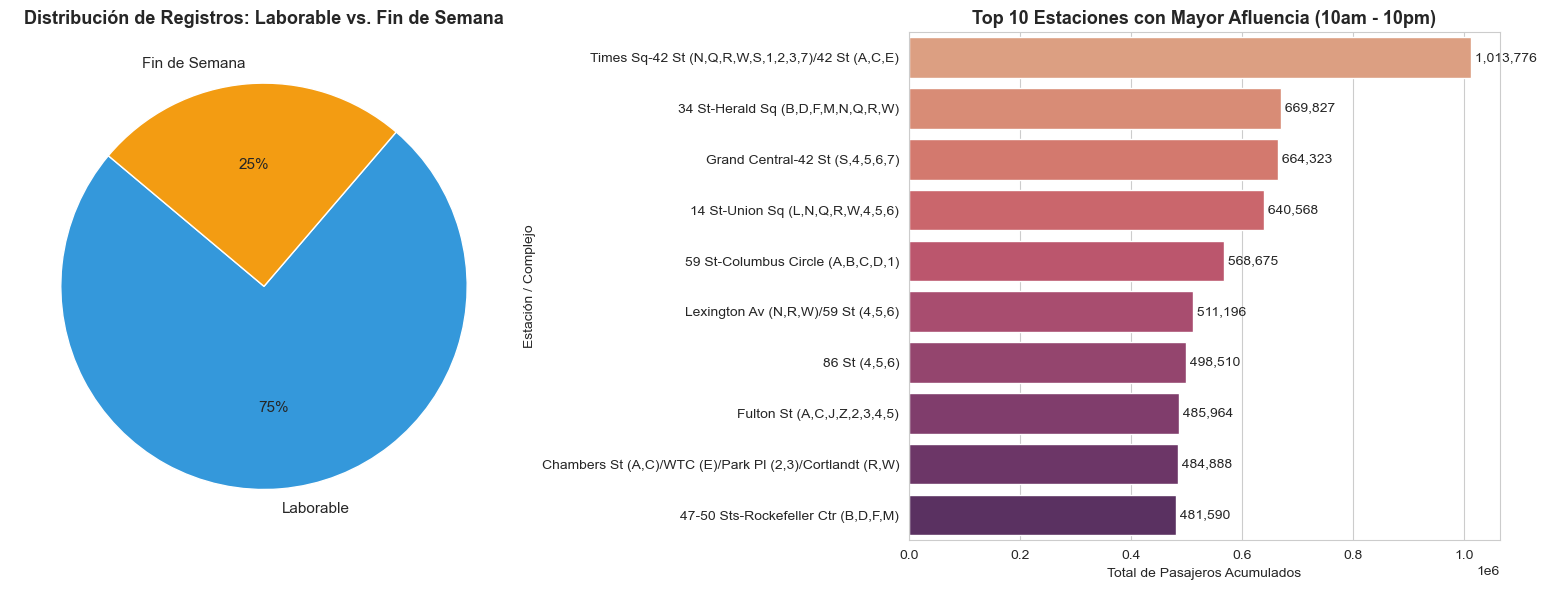

In [32]:
# PASO 6: ANÁLISIS EXPLORATORIO DE DATOS (EDA) - MTA
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo y dimensiones
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6)) 

# --- GRÁFICO 1: Pastel - Distribución por Tipo de Día ---
plt.subplot(1, 2, 1)
conteo_dia = df_final['TIPO_DIA'].value_counts()

colores_pie = ['#3498db', '#f39c12'] 
plt.pie(conteo_dia, labels=conteo_dia.index, autopct='%1.f%%', startangle=140, 
        colors=colores_pie, textprops={'fontsize': 11})
plt.title('Distribución de Registros: Laborable vs. Fin de Semana', fontsize=13, fontweight='bold')

# --- GRÁFICO 2: Barras - Top 10 Estaciones con Mayor Afluencia ---
plt.subplot(1, 2, 2) 

top_estaciones = df_final.groupby('ESTACION')['PASAJEROS'].sum().sort_values(ascending=False).head(10) #agrupacion por estacion

# Creación del gráfico de barras horizontales
grafico_barras = sns.barplot(x=top_estaciones.values, y=top_estaciones.index, 
                             hue=top_estaciones.index, palette="flare", legend=False)

plt.title('Top 10 Estaciones con Mayor Afluencia (10am - 10pm)', fontsize=13, fontweight='bold')
plt.xlabel('Total de Pasajeros Acumulados')
plt.ylabel('Estación / Complejo')

# Etiquetas
for i in range(len(top_estaciones)):
    plt.text(top_estaciones.values[i], i, f' {int(top_estaciones.values[i]):,}', 
             va='center', fontsize=10)

plt.tight_layout()
plt.show()

In [35]:
# PASO 7: EXPORTACIÓN FINAL DEL DATASET (MTA)

import os

# Definición del nombre del archivo y ruta para guardar
carpeta = '../../datos/limpios/movilidad'
nombre_archivo = '10_MTA_Manhattan.csv'
ruta_completa = os.path.join(carpeta, nombre_archivo)

try:
    # Guardamos el CSV
    # encoding='utf-8-sig' para asegurar la correcta lectura de caracteres especiales
    df_final.to_csv(ruta_completa, index=False, encoding='utf-8-sig')
    
    print(f"\n💾 ¡EXPORTACIÓN EXITOSA!")
    print("-" * 70)
    print(f"📂 Archivo guardado en: {ruta_completa}")
    print(f"📊 Filas exportadas: {df_final.shape[0]:,}")

except Exception as e:
    print(f"❌ Error al guardar el archivo: {e}")


💾 ¡EXPORTACIÓN EXITOSA!
----------------------------------------------------------------------
📂 Archivo guardado en: Datos_Limpios\10_MTA_Manhattan_II.csv
📊 Filas exportadas: 465,343
